In [ ]:
#This tab we are going to import all the necessary libraries

#importing pandas and matplot
import pandas as pd
import matplotlib.pyplot as plt

#import math libraries
from sklearn.metrics import mean_squared_error
import numpy as np

#importing the train and test split
from sklearn.model_selection import train_test_split

#importing the pipline libraries to clean up the data if necessary
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

#calssification report for the f1 score
from sklearn.metrics import classification_report

#importing the SGDClassifier
from sklearn.linear_model import SGDClassifier


#confusion matrix
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

#precision score
from sklearn.metrics import precision_score, recall_score

#recall curve and cross value curve
from sklearn.metrics import precision_recall_curve
from sklearn.model_selection import cross_val_predict

#imports for support vector machines
from sklearn.svm import LinearSVC
from sklearn.preprocessing import PolynomialFeatures
from sklearn.svm import SVC
from sklearn.svm import LinearSVR
from sklearn.svm import SVR

#imports for descision tree classifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import export_graphviz
from graphviz import Source
from sklearn.tree import DecisionTreeRegressor

#imports for random forest
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

In [ ]:
data = pd.read_csv("GUIDE_test_clean.csv")
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1214523 entries, 0 to 1214522
Data columns (total 13 columns):
 #   Column          Non-Null Count    Dtype 
---  ------          --------------    ----- 
 0   OSVersion       1214523 non-null  int64 
 1   OSFamily        1214523 non-null  int64 
 2   IpAddress       1214523 non-null  int64 
 3   IncidentId      1214523 non-null  int64 
 4   DetectorId      1214523 non-null  int64 
 5   CountryCode     1214523 non-null  int64 
 6   State           1214523 non-null  int64 
 7   Id              1214523 non-null  int64 
 8   OrgId           1214523 non-null  int64 
 9   AlertId         1214523 non-null  int64 
 10  AlertTitle      1214523 non-null  int64 
 11  IncidentGrade   1214523 non-null  object
 12  SuspicionLevel  189666 non-null   object
dtypes: int64(11), object(2)
memory usage: 120.5+ MB


In [ ]:
data.head()

,OSVersion,OSFamily,IpAddress,IncidentId,DetectorId,CountryCode,State,Id,OrgId,AlertId,AlertTitle,IncidentGrade,SuspicionLevel
0,66,5,360606,11767,524,242,1445,1245540519230,657,87199,563,BenignPositive,Suspicious
1,0,0,360606,91158,2,242,1445,1400159342154,3,632273,2,BenignPositive,Suspicious
2,66,5,360606,32247,2932,242,1445,1279900255923,145,131719,10807,BenignPositive,Suspicious
3,66,5,360606,15294,0,242,1445,60129547292,222,917686,0,FalsePositive,NaN
4,66,5,360606,7615,27,242,1445,515396080539,363,5944,18,BenignPositive,NaN


**SGD CLASSIFIER**

In [ ]:
#SGDClassifier model
#in this model we are going to predict and detect the OSFamily
#we are going to drop all missing values

sgd_data = data.dropna()

#splitting the data into the train and test sets
sgd_train_set, sgd_test_set = train_test_split(sgd_data, test_size=0.2, random_state=10)

#making a train and test input and output/labels
sgd_train = sgd_train_set.drop('OSFamily', axis = 1)
sgd_train_labels = sgd_train_set["OSFamily"].copy()

sgd_test = sgd_test_set.drop('OSFamily', axis = 1)
sgd_test_labels = sgd_test_set["OSFamily"].copy()

sgd_data.head()

,OSVersion,OSFamily,IpAddress,IncidentId,DetectorId,CountryCode,State,Id,OrgId,AlertId,AlertTitle,IncidentGrade,SuspicionLevel
0,66,5,360606,11767,524,242,1445,1245540519230,657,87199,563,BenignPositive,Suspicious
1,0,0,360606,91158,2,242,1445,1400159342154,3,632273,2,BenignPositive,Suspicious
2,66,5,360606,32247,2932,242,1445,1279900255923,145,131719,10807,BenignPositive,Suspicious
6,66,5,360606,105333,3,242,1445,1194000913330,133,732769,4,BenignPositive,Suspicious
11,66,5,194296,15377,1143,242,1445,1649267446378,103,696227,2083,TruePositive,Suspicious


In [ ]:
#creating the pipeline for the code to be catagorized and prepared
num_attribs = ["OSVersion","IpAddress","IncidentId","DetectorId","CountryCode","State","Id", "OrgId", "AlertId", "AlertTitle"]
cat_attribs = ["IncidentGrade", "SuspicionLevel"]

num_pipeline = Pipeline([("standardize", StandardScaler()),])

cat_pipeline = Pipeline([("oneHot", OneHotEncoder()),])

preprocessing = ColumnTransformer([("num", num_pipeline, num_attribs),("cat", cat_pipeline, cat_attribs),])

#creating the two prepared data sets for train and test
sgd_train_prepared = preprocessing.fit_transform(sgd_train)

sgd_test_prepared = preprocessing.fit_transform(sgd_test)

In [ ]:
#Train the SGDClassifier model for the train set

sgd_clf = SGDClassifier(random_state = 42)
sgd_clf1 = SGDClassifier(random_state = 42)
sgd_clf.fit(sgd_train_prepared, sgd_train_labels)


SGDClassifier(random_state=42)

In [ ]:
#train teh SGDClassifier model for the test set

sgd_clf1.fit(sgd_test_prepared, sgd_test_labels)

SGDClassifier(random_state=42)

In [ ]:
#we will run the predictions on both the train and test model and save the predictions
#to another variable

var_train = sgd_clf.predict(sgd_train_prepared)
print("Train prediction saved: ", var_train)

var_test = sgd_clf1.predict(sgd_test_prepared)
print("Test prediction saved: ", var_test)


Train prediction saved:  [5 0 5 ... 5 5 5]
Test prediction saved:  [5 0 5 ... 5 5 5]


In [ ]:
#confusion matrix for train set

train_conf = confusion_matrix(sgd_train_labels, var_train)
train_conf



array([[ 65286,      0,      0,     63],
       [   552,     57,      0,    171],
       [   536,     22,      1,     62],
       [     0,      0,      0, 453118]])

In [ ]:
#confusion matrix for test data set
test_conf = confusion_matrix(sgd_test_labels, var_test)
test_conf


array([[ 16596,      0,      0,      8],
       [   175,      7,      0,     35],
       [   133,      0,      0,      8],
       [     0,      0,      0, 113005]])

In [ ]:
#precision score for the train data set
train_precision = precision_score(sgd_train_labels, var_train, average = 'weighted')
print("train precision score: ",train_precision)

train precision score:  0.9969526491456588


In [ ]:
#precision score for the test data set
test_precision= precision_score(sgd_test_labels, var_test, average = 'weighted')
print("test precision score: ", test_precision)

test precision score:  0.9961951046662071


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
#recall score for both the train and test data set
train_recall = recall_score(sgd_train_labels, var_train, average = 'weighted')
test_recall = recall_score(sgd_test_labels, var_test, average = 'weighted')

print("SGD train recall score: ", train_recall)
print("SGD test recall score: ", test_recall)


train recall score:  0.9972954673109328
test recall score:  0.9972377603545516


In [ ]:
#classification report for both the train and test data sets

class_train = classification_report(sgd_train_labels, var_train)

class_test = classification_report(sgd_test_labels, var_test)

print("Classification SGD for train: ")
print(class_train)
print("Classification SGD for test: ")
print(class_test)

Classification for train: 
              precision    recall  f1-score   support

           0       0.98      1.00      0.99     65349
           1       0.72      0.07      0.13       780
           2       1.00      0.00      0.00       621
           5       1.00      1.00      1.00    453118

    accuracy                           1.00    519868
   macro avg       0.93      0.52      0.53    519868
weighted avg       1.00      1.00      1.00    519868

Classification for test: 
              precision    recall  f1-score   support

           0       0.98      1.00      0.99     16604
           1       1.00      0.03      0.06       217
           2       0.00      0.00      0.00       141
           5       1.00      1.00      1.00    113005

    accuracy                           1.00    129967
   macro avg       0.75      0.51      0.51    129967
weighted avg       1.00      1.00      1.00    129967



/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


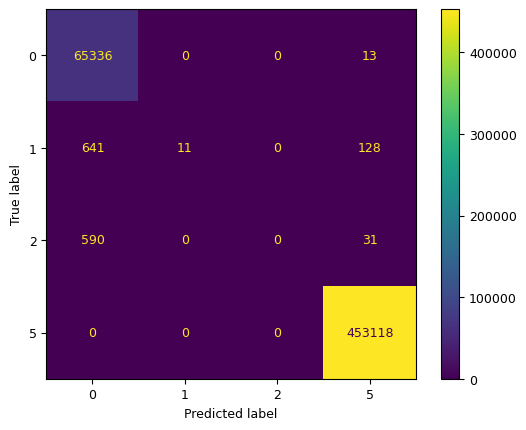

In [ ]:
#generating a confusion matrix diagram to easily detect the OSVersions per attack
y_pred = cross_val_predict(sgd_clf, sgd_train_prepared, sgd_train_labels, cv = 5)
plt.rc('font', size = 9)
ConfusionMatrixDisplay.from_predictions(sgd_train_labels, y_pred)
plt.show()

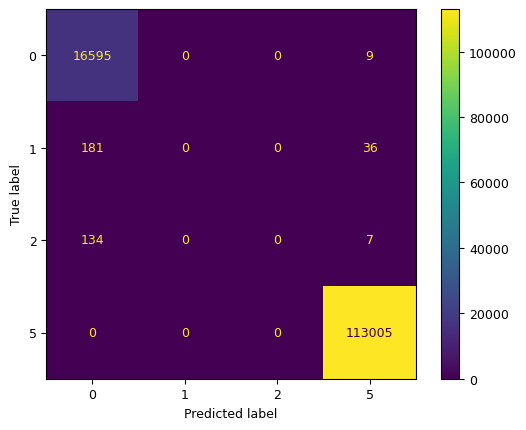

In [ ]:
#generating a confusion matrix diagram for test data set
y_pred_test = cross_val_predict(sgd_clf, sgd_test_prepared, sgd_test_labels, cv = 5)
plt.rc('font', size = 9)
ConfusionMatrixDisplay.from_predictions(sgd_test_labels, y_pred_test)
plt.show()

**SUPPORT VECTOR MACHINE PREDICTIONS**

In [ ]:
#we are going to send the data through a pipline to catagorize it and make
#sure it is ready for the svm model
svm_data = data.dropna()

#splitting the data into the train and test sets
svm_train_set, svm_test_set = train_test_split(svm_data, test_size=0.2, random_state=10)

#making a train and test input and output/labels
svm_train = svm_train_set.drop('OSFamily', axis = 1)
svm_train_labels = svm_train_set["OSFamily"].copy()

svm_test = svm_test_set.drop('OSFamily', axis = 1)
svm_test_labels = svm_test_set["OSFamily"].copy()

num_attribs = ["OSVersion","IpAddress","IncidentId","DetectorId","CountryCode","State","Id", "OrgId", "AlertId", "AlertTitle"]
cat_attribs = ["IncidentGrade", "SuspicionLevel"]

num_pipeline = Pipeline([("standardize", StandardScaler()),])

cat_pipeline = Pipeline([("oneHot", OneHotEncoder()),])

preprocessing = ColumnTransformer([("num", num_pipeline, num_attribs),("cat", cat_pipeline, cat_attribs),])

#creating the two prepared data sets for train and test
svm_train_prepared = preprocessing.fit_transform(svm_train)

svm_test_prepared = preprocessing.fit_transform(svm_test)


confusion matrix: 
SVM train confusion matrix: 


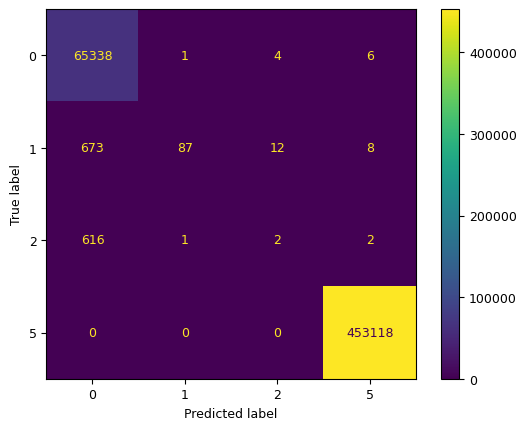

precision train score:  0.9964417839073518
recall train score:  0.9974551232235875


In [ ]:
#This will create the svm linear to make a confusion matrix prediction for the train data set
#This will use Linear SVC from sklearn

svm_clf = LinearSVC(C=1, random_state = 42)
svm_clf.fit(svm_train_prepared, svm_train_labels)

y_pred_train = cross_val_predict(svm_clf, svm_train_prepared, svm_train_labels, cv=3)
conf_train = confusion_matrix(svm_train_labels, y_pred)

print("confusion matrix: ")
plt.rc('font', size = 9)
ConfusionMatrixDisplay.from_predictions(svm_train_labels, y_pred_train)
print("SVM train confusion matrix: ")
plt.show()
print("precision train score: ", precision_score(svm_train_labels, y_pred_train, average = 'weighted'))
print("recall train score: ", recall_score(svm_train_labels, y_pred_train, average = 'weighted'))

SVM test confusion matrix: 


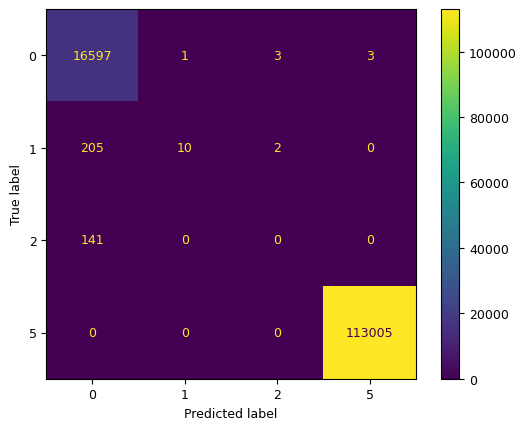

precision test score:  0.9961312922965901
recall test score:  0.9972685373979548


In [ ]:
#This will create the svm linear to make a confusion matrix prediction for the test data set
#This will use Linear SVC from sklearn

svm_clf1 = LinearSVC(C=1, random_state = 42)
svm_clf1.fit(svm_test_prepared, svm_test_labels)

y_pred_test = cross_val_predict(svm_clf1, svm_test_prepared, svm_test_labels, cv=3)
conf_test = confusion_matrix(svm_test_labels, y_pred_test)


ConfusionMatrixDisplay.from_predictions(svm_test_labels, y_pred_test)
print("SVM test confusion matrix: ")
plt.show()
print("precision test score: ", precision_score(svm_test_labels, y_pred_test, average = 'weighted'))
print("recall test score: ", recall_score(svm_test_labels, y_pred_test, average = 'weighted'))

In [ ]:
#this is the classification report for the train and test
#the reason for the classification report is to get the f1-score
class_train_svm = classification_report(svm_train_labels, y_pred_train)
class_test_svm = classification_report(svm_test_labels, y_pred_test)
print("SVM Train classification report")
print(class_train_svm)
print("SVM Test classification report")
print(class_test_svm)

SVM Train classification report
              precision    recall  f1-score   support

           0       0.98      1.00      0.99     65349
           1       0.98      0.11      0.20       780
           2       0.11      0.00      0.01       621
           5       1.00      1.00      1.00    453118

    accuracy                           1.00    519868
   macro avg       0.77      0.53      0.55    519868
weighted avg       1.00      1.00      1.00    519868

SVM Test classification report
              precision    recall  f1-score   support

           0       0.98      1.00      0.99     16604
           1       0.91      0.05      0.09       217
           2       0.00      0.00      0.00       141
           5       1.00      1.00      1.00    113005

    accuracy                           1.00    129967
   macro avg       0.72      0.51      0.52    129967
weighted avg       1.00      1.00      1.00    129967



**DECISION TREE MODEL**

In [ ]:
#clean the data and send it through a pipeline to catagorize it then split
# it into two prepared data sets for train and test data sets

dec_data = data.dropna()

#splitting the data into the train and test sets
dec_train_set, dec_test_set = train_test_split(dec_data, test_size=0.2, random_state=10)

#making a train and test input and output/labels
dec_train = dec_train_set.drop('OSFamily', axis = 1)
dec_train_labels = dec_train_set["OSFamily"].copy()

dec_test = dec_test_set.drop('OSFamily', axis = 1)
dec_test_labels = dec_test_set["OSFamily"].copy()

num_attribs = ["OSVersion","IpAddress","IncidentId","DetectorId","CountryCode","State","Id", "OrgId", "AlertId", "AlertTitle"]
cat_attribs = ["IncidentGrade", "SuspicionLevel"]

num_pipeline = Pipeline([("standardize", StandardScaler()),])

cat_pipeline = Pipeline([("oneHot", OneHotEncoder()),])

preprocessing = ColumnTransformer([("num", num_pipeline, num_attribs),("cat", cat_pipeline, cat_attribs),])

#creating the two prepared data sets for train and test
dec_train_prepared = preprocessing.fit_transform(dec_train)

dec_test_prepared = preprocessing.fit_transform(dec_test)


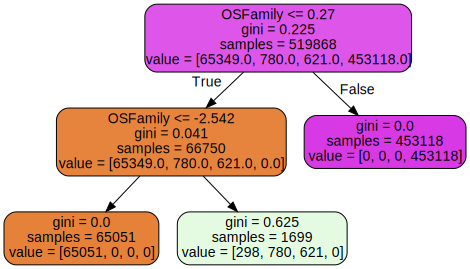

In [ ]:
#creating the descision tree classifier to create the graph for the train data set
tree_clf_graph = DecisionTreeClassifier(max_depth = 2, random_state = 42)
tree_clf_graph.fit(dec_train_prepared, dec_train_labels)

export_graphviz(
    tree_clf_graph,
    out_file = str("classification_tree.dot"),
    feature_names = ["OSFamily","OSVersion","IpAddress","IncidentId","DetectorId","CountryCode","State","Id", "OrgId", "AlertId", "AlertTitle","Incidentgrade",
                     "suspicionlevel","13","14"],
    #class_names=["IncidentGrade", "SuspicionLevel"],
    rounded = True,
    filled = True
)
Source.from_file("classification_tree.dot")

Decision Tree train confusion matrix: 


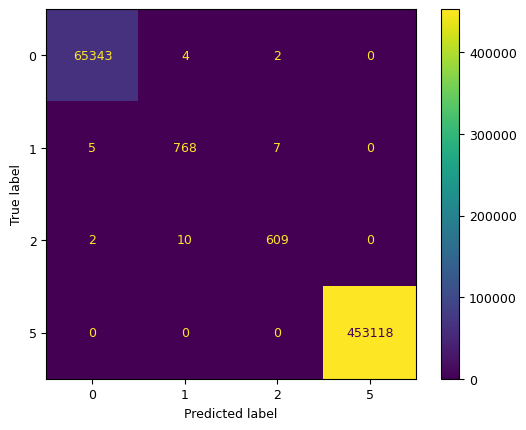

In [ ]:
#creating the confusion matrix for train
tree_clf_train = DecisionTreeClassifier(max_depth = 20, random_state = 42)
tree_clf_train.fit(dec_train_prepared, dec_train_labels)

y_pred_train_dec = cross_val_predict(tree_clf_train, dec_train_prepared, dec_train_labels, cv = 5)
dec_conf_train = confusion_matrix(dec_train_labels, y_pred_train_dec)

plt.rc('font', size = 9)
ConfusionMatrixDisplay.from_predictions(dec_train_labels, y_pred_train_dec)
print("Decision Tree train confusion matrix: ")
plt.show()

Decision Tree test confusion matrix: 


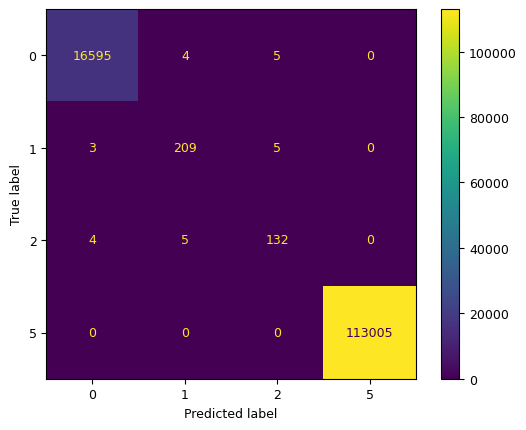

In [ ]:
#confusion matrix for test data set

tree_clf_test = DecisionTreeClassifier(max_depth = 20, random_state = 42)
tree_clf_test.fit(dec_test_prepared, dec_test_labels)

y_pred_test_dec = cross_val_predict(tree_clf_test, dec_test_prepared, dec_test_labels, cv = 5)
dec_conf_test = confusion_matrix(dec_test_labels, y_pred_test_dec)
plt.rc('font', size = 9)
ConfusionMatrixDisplay.from_predictions(dec_test_labels, y_pred_test_dec)
print("Decision Tree test confusion matrix: ")
plt.show()

In [ ]:
#precision and recall score for both the train and test data sets

print("precision score train: ", precision_score(dec_train_labels, y_pred_train_dec, average = 'weighted'))
print("Recall score train: ", recall_score(dec_train_labels, y_pred, average = 'weighted'))

print("")

print("precision score test: ", precision_score(dec_test_labels, y_pred_test_dec, average = 'weighted'))
print("recall score test: ", recall_score(dec_test_labels, y_pred_test_dec, average = 'weighted'))


precision score train:  0.9999422780848634
Recall score train:  0.9973012380065709

precision score test:  0.999800802231851
recall score test:  0.9997999492178784


In [ ]:
#the classification report where we will get the f1 score for both the
#train and test data sets

class_train_dec = classification_report(dec_train_labels, y_pred_train_dec)
class_test_dec = classification_report(dec_test_labels, y_pred_test_dec)
print("decision Train classification report")
print(class_train_dec)
print("decision Test classification report")
print(class_test_dec)

dec Train classification report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     65349
           1       0.98      0.98      0.98       780
           2       0.99      0.98      0.98       621
           5       1.00      1.00      1.00    453118

    accuracy                           1.00    519868
   macro avg       0.99      0.99      0.99    519868
weighted avg       1.00      1.00      1.00    519868

dec Test classification report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     16604
           1       0.96      0.96      0.96       217
           2       0.93      0.94      0.93       141
           5       1.00      1.00      1.00    113005

    accuracy                           1.00    129967
   macro avg       0.97      0.97      0.97    129967
weighted avg       1.00      1.00      1.00    129967



**RANDOM FOREST**

In [ ]:
#creating the pipline random forest pipline and then
#splitting the data into an input and output and preparing those
#values into the preparation train and data sets



forest_data = data.dropna()

#splitting the data into the train and test sets
forest_train_set, forest_test_set = train_test_split(forest_data, test_size=0.2, random_state=10)

#making a train and test input and output/labels
forest_train = forest_train_set.drop('OSFamily', axis = 1)
forest_train_labels = forest_train_set["OSFamily"].copy()

forest_test = forest_test_set.drop('OSFamily', axis = 1)
forest_test_labels = forest_test_set["OSFamily"].copy()

num_attribs = ["OSVersion","IpAddress","IncidentId","DetectorId","CountryCode","State","Id", "OrgId", "AlertId", "AlertTitle"]
cat_attribs = ["IncidentGrade", "SuspicionLevel"]

num_pipeline = Pipeline([("standardize", StandardScaler()),])

cat_pipeline = Pipeline([("oneHot", OneHotEncoder()),])

preprocessing = ColumnTransformer([("num", num_pipeline, num_attribs),("cat", cat_pipeline, cat_attribs),])

#creating the two prepared data sets for train and test
forest_train_prepared = preprocessing.fit_transform(forest_train)

forest_test_prepared = preprocessing.fit_transform(forest_test)

In [ ]:
#this is the creation of the random forest model with 500 trees
# on the prepared train data set

rnd_clf_train = RandomForestClassifier(n_estimators=500, random_state = 42)
rnd_clf_train.fit(forest_train_prepared, forest_train_labels)


y_pred_forest_train = cross_val_predict(rnd_clf_train, forest_train_prepared, forest_train_labels, cv = 3)
cm = confusion_matrix(forest_train_labels, y_pred_forest_train)


plt.rc('font', size = 9)
ConfusionMatrixDisplay.from_predictions(forest_train_labels, y_pred_forest_train)
print("Forest Tree train confusion matrix: ")
plt.show()


NameError: name 'RandomForestClassifier' is not defined

Forest Tree test confusion matrix: 


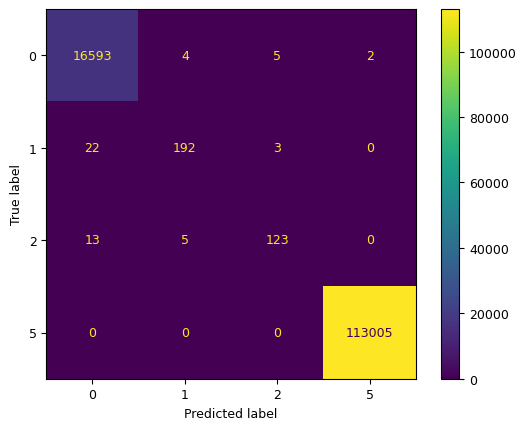

In [ ]:
#this is the creation of the random forest model with 500 trees
# on th prepared test data set

rnd_clf_test = RandomForestClassifier(n_estimators=500, random_state=42)
rnd_clf_test.fit(forest_test_prepared, forest_test_labels)

y_pred_forest_test = cross_val_predict(rnd_clf_test, forest_test_prepared, forest_test_labels, cv = 3)
cm = confusion_matrix(forest_test_labels, y_pred_forest_test)


plt.rc('font', size = 9)
ConfusionMatrixDisplay.from_predictions(forest_test_labels, y_pred_forest_test)
print("Forest Tree test confusion matrix: ")
plt.show()

In [ ]:
#precision score and recall score for the train data set

print("precision score train: ", precision_score(forest_train_labels, y_pred_forest_train, average = 'weighted'))
print("recall score train: ", recall_score(forest_train_labels, y_pred_forest_train, average = 'weighted'))

for score, name in zip(rnd_clf_train.feature_importances_, preprocessing.get_feature_names_out()):
    print(round(score, 2), name)

precision score train:  0.9999051610233268
recall score train:  0.9999057453045773
0.94 num__OSVersion
0.0 num__IpAddress
0.0 num__IncidentId
0.02 num__DetectorId
0.0 num__CountryCode
0.0 num__State
0.0 num__Id
0.0 num__OrgId
0.02 num__AlertId
0.01 num__AlertTitle
0.0 cat__IncidentGrade_BenignPositive
0.0 cat__IncidentGrade_FalsePositive
0.0 cat__IncidentGrade_TruePositive
0.0 cat__SuspicionLevel_Incriminated
0.0 cat__SuspicionLevel_Suspicious


In [ ]:
#precision score and recalls core for the test data set
print("precision score test: ", precision_score(forest_test_labels, y_pred_forest_test, average = 'weighted'))
print("recall score test: ", recall_score(forest_test_labels, y_pred_forest_test, average = 'weighted'))

for score, name in zip(rnd_clf_test.feature_importances_, preprocessing.get_feature_names_out()):
    print(round(score, 2), name)

precision score test:  0.9995746877873813
recall score test:  0.9995845099140551
0.93 num__OSVersion
0.0 num__IpAddress
0.0 num__IncidentId
0.02 num__DetectorId
0.0 num__CountryCode
0.0 num__State
0.0 num__Id
0.01 num__OrgId
0.02 num__AlertId
0.02 num__AlertTitle
0.0 cat__IncidentGrade_BenignPositive
0.0 cat__IncidentGrade_FalsePositive
0.0 cat__IncidentGrade_TruePositive
0.0 cat__SuspicionLevel_Incriminated
0.0 cat__SuspicionLevel_Suspicious


In [ ]:
#classification report for the f1 score on both the train and test data set


class_train_forest = classification_report(forest_train_labels, y_pred_forest_train)
class_test_forest = classification_report(forest_test_labels, y_pred_forest_test)
print("Forest Tree Train classification report")
print(class_train_forest)
print("Forest Tree Test classification report")
print(class_test_forest)

Forest Tree Train classification report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     65349
           1       0.98      0.98      0.98       780
           2       0.98      0.96      0.97       621
           5       1.00      1.00      1.00    453118

    accuracy                           1.00    519868
   macro avg       0.99      0.98      0.99    519868
weighted avg       1.00      1.00      1.00    519868

Forest Tree Test classification report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     16604
           1       0.96      0.88      0.92       217
           2       0.94      0.87      0.90       141
           5       1.00      1.00      1.00    113005

    accuracy                           1.00    129967
   macro avg       0.97      0.94      0.96    129967
weighted avg       1.00      1.00      1.00    129967

